# Classification des œuvres de Zola et d'autres naturalistes

## Expérience avec retrait d'une liste de noms propres

## 1. Importation des bibliothèques

In [1]:
# Fichiers et données
import os
import glob
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Représentation textuelle
from sklearn.feature_extraction.text import TfidfVectorizer

# Modèles
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Pipelines et validation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Toutes les bibliothèques sont chargées.")

Toutes les bibliothèques sont chargées.


## 2. Normalisation des apostrophes

Les textes ayant été préalablement nettoyés, certaines apostrophes ont
disparu. Cette étape restaure les contractions les plus fréquentes à partir
d'un dictionnaire de correspondances.

N.b: Les formes `dune` et `lune` sont respectivement interprétées comme `d'une`
et `l'une`. Ce choix repose sur l'hypothèse que les occurrences des noms
communs *dune* et *lune* sont minoritaires dans le corpus étudié.

In [2]:
REMPLACEMENTS_APOSTROPHES = {
    # ========================================================
    # Locutions longues : à traiter avant les formes courtes
    # ========================================================
    "lorsquil": "lorsqu'il",
    "lorsquils": "lorsqu'ils",
    "lorsquon": "lorsqu'on",
    "lorsquune": "lorsqu'une",
    "lorsquun": "lorsqu'un",
    "lorsquelle": "lorsqu'elle",
    "lorsquelles": "lorsqu'elles",

    "puisquil": "puisqu'il",
    "puisquils": "puisqu'ils",
    "puisquon": "puisqu'on",
    "puisquune": "puisqu'une",
    "puisquun": "puisqu'un",
    "puisquelle": "puisqu'elle",
    "puisquelles": "puisqu'elles",

    "quoiquil": "quoiqu'il",
    "quoiquils": "quoiqu'ils",
    "quoiquon": "quoiqu'on",
    "quoiquelle": "quoiqu'elle",

    "jusquil": "jusqu'il",
    "jusquils": "jusqu'ils",
    "jusquon": "jusqu'on",
    "jusquune": "jusqu'une",
    "jusquun": "jusqu'un",
    "jusquelle": "jusqu'elle",
    "jusquelles": "jusqu'elles",
    "jusquà": "jusqu'à",
    "jusquau": "jusqu'au",
    "jusquaux": "jusqu'aux",

    # ========================================================
    # Contractions avec c'
    # ========================================================
    "cest": "c'est",
    "cétait": "c'était",
    "cétaient": "c'étaient",
    "cétant": "c'étant",
    "cen": "c'en",

    # ========================================================
    # Contractions avec s'
    # ========================================================
    "sest": "s'est",
    "sétait": "s'était",
    "sétaient": "s'étaient",
    "sétant": "s'étant",
    "sen": "s'en",
    "sy": "s'y",
    "sil": "s'il",
    "sils": "s'ils",

    # ========================================================
    # Contractions avec n'
    # ========================================================
    "nest": "n'est",
    "nétait": "n'était",
    "nétaient": "n'étaient",
    "navait": "n'avait",
    "navaient": "n'avaient",
    "naurait": "n'aurait",
    "nauraient": "n'auraient",
    "naura": "n'aura",
    "nauront": "n'auront",
    "na": "n'a",
    "nont": "n'ont",
    "nen": "n'en",
    "ny": "n'y",
    "navoir": "n'avoir",
    "nêtre": "n'être",
    "nai": "n'ai",
    "navez": "n'avez",

    # ========================================================
    # Contractions avec j'
    # ========================================================
    "jai": "j'ai",
    "javais": "j'avais",
    "jétais": "j'étais",
    "jaurais": "j'aurais",
    "jaurai": "j'aurai",
    "jaime": "j'aime",
    "jallais": "j'allais",
    "jignore": "j'ignore",
    "jentends": "j'entends",
    "jen": "j'en",
    "jy": "j'y",

    # ========================================================
    # Contractions avec qu'
    # ========================================================
    "quest": "qu'est",
    "quil": "qu'il",
    "quils": "qu'ils",
    "quon": "qu'on",
    "quun": "qu'un",
    "quune": "qu'une",
    "quà": "qu'à",
    "quen": "qu'en",


    # ========================================================
    # Contractions avec d'
    # ========================================================
    "dune": "d'une", #je prend le parti de mettre d'apostrophe mais il y a un risque de confusion avec "d'une" (de une) et "dune" (la dune) 
    "dun": "d'un",
    "delle": "d'elle",
    "delles": "d'elles",
    "dêtre": "d'être",
    "davoir": "d'avoir",
    "dabord": "d'abord",
    "dailleurs": "d'ailleurs",
    "daprès": "d'après",
    "daccord": "d'accord",
    "davance": "d'avance",
    "doù": "d'où",
    "dautres": "d'autres",
    "damour": "d'amour",
    "dargent": "d'argent",
    "despoir": "d'espoir",
    "den": "d'en",
    "desprit": "d'esprit",
    'deau': "d'eau",

    # ========================================================
    # Contractions avec l'
    # ========================================================
    "labbé": "l'abbé",
    "lair": "l'air",
    "lâme": "l'âme",
    "lami": "l'ami",
    "lamie": "l'amie",
    "lamour": "l'amour",
    "largent": "l'argent",
    "lautre": "l'autre",
    "lun": "l'un",
    "lune": "l'une",
    "lheure": "l'heure",
    "lhomme": "l'homme",
    "lhonneur": "l'honneur",
    "lhistoire": "l'histoire",
    "lhôtel": "l'hôtel",
    "léglise": "l'église",
    "lépoque": "l'époque",
    "lenfant": "l'enfant",
    "lendroit": "l'endroit",
    "lentrée": "l'entrée",
    "lintérieur": "l'intérieur",
    "lidée": "l'idée",
    "lombre": "l'ombre",
    "loeil": "l'œil",
    "lœil": "l'œil",
    "lon": "l'on",
    "lai": "l'ai",
    "lavait": "l'avait",
    "leau": "l'eau",
    "lesprit": "l'esprit",
    "lescalier": "l'escalier",
    "létudiant": "l'étudiant",
    'lavenir': "l'avenir",
    "laffaire": "l'affaire",
    "loreille": "l'oreille",
    "lavocat": "l'avocat",

    # ========================================================
    # Locutions courantes
    # ========================================================
    "aujourdhui": "aujourd'hui",
    "presquun": "presqu'un",
    "presquune": "presqu'une",
    "quelquun": "quelqu'un",
    "quelquune": "quelqu'une",

    # ========================================================
    # Verbes pronominaux fréquemment rencontrés
    # ========================================================
    "sécria": "s'écria",
    "sécriait": "s'écriait",
    "sécrièrent": "s'écrièrent",
    "saperçut": "s'aperçut",
    "sapercevait": "s'apercevait",
    "sapprocha": "s'approcha",
    "sapprochait": "s'approchait",
    "sarrêta": "s'arrêta",
    "sarrêtait": "s'arrêtait",
    "sassit": "s'assit",
    "sétendit": "s'étendit",
    "séloigna": "s'éloigna",
    "séloignait": "s'éloignait",
    
    # m'
    "men": "m'en",
    "mavez": "m'avez",
    "mavait": "m'avait",
    
    "daller": "d'aller",
    "lappartement": "l'appartement",
    "lhuile": "l'huile",
    "mest": "m'est",
    "dhonneur": "d'honneur",
    "dici": "d'ici",
    "neût": "n'eût",
    "sécrie": "s'écrie",
    "ce quelle": "ce qu'elle",
    "ten": "t'en",
    "dhenriette": "d'Henriette",
    "lart": "l'art",
    "quau": "qu'au",
    "quaux": "qu'aux",
    "dautre": "d'autre",
    "dautres": "d'autres",
    "navais": "n'avais",
    "navions": "n'avions",
    "sagit": "s'agit",
    
}

def adapter_casse(forme_originale, remplacement):
    """Conserve approximativement la casse du mot d'origine."""

    if forme_originale.isupper():
        return remplacement.upper()

    if forme_originale[0].isupper():
        return remplacement[0].upper() + remplacement[1:]

    return remplacement


def restaurer_apostrophes(texte):
    """Restaure certaines apostrophes supprimées avec une forte confiance."""

    remplacements_tries = sorted(
        REMPLACEMENTS_APOSTROPHES.items(),
        key=lambda element: len(element[0]),
        reverse=True
    )

    for forme_nettoyee, forme_corrigee in remplacements_tries:
        motif = rf"\b{re.escape(forme_nettoyee)}\b"

        texte = re.sub(
            motif,
            lambda correspondance: adapter_casse(
                correspondance.group(0),
                forme_corrigee
            ),
            texte,
            flags=re.IGNORECASE
        )

    return texte

## 3. Segmentation des fichiers en blocs de 3 lignes

In [ ]:
def segmenter_en_paquets(texte, taille_paquet=3):
    lignes = texte.splitlines()
    lignes = [ligne.strip() for ligne in lignes if ligne.strip()]

    paquets = []

    for i in range(0, len(lignes), taille_paquet):
        paquet = " ".join(lignes[i:i + taille_paquet])
        if paquet:
            paquets.append(paquet)
    return paquets


def determiner_label(nom_fichier):
    if nom_fichier.endswith("clean.txt"):
        return "Zola"
    return "naturaliste"


def construire_dataframe(liste_fichiers):
    donnees = []

    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        label = determiner_label(nom_fichier)

        with open(chemin_fichier, "r", encoding="utf-8") as fichier:
            texte = fichier.read()
        # Restauration appliquée aux deux corpus
        texte = restaurer_apostrophes(texte)
        blocs = segmenter_en_paquets(
            texte)
        for bloc in blocs:
            donnees.append({
                "texte": bloc,
                "label": label,
                "source": nom_fichier
            })
    return pd.DataFrame(donnees)

chemin_dossier = "Z_vs_N"

liste_fichiers = sorted(glob.glob(os.path.join(chemin_dossier, "*.txt")))

print(f"Nombre de fichiers trouvés : {len(liste_fichiers)}")

random.seed(4)
random.shuffle(liste_fichiers)

liste_train = liste_fichiers[:44]
liste_test = liste_fichiers[44:]

df_train = construire_dataframe(liste_train)
df_test = construire_dataframe(liste_test)

print("\nTRAIN")
print(df_train["label"].value_counts())
print("Nombre d'œuvres :", df_train["source"].nunique())

print("\nTEST")
print(df_test["label"].value_counts())
print("Nombre d'œuvres :", df_test["source"].nunique())

Nombre de fichiers trouvés : 56

TRAIN
label
Zola           31217
naturaliste    29974
Name: count, dtype: int64
Nombre d'œuvres : 44

TEST
label
Zola           15121
naturaliste     4915
Name: count, dtype: int64
Nombre d'œuvres : 12


## 4. Vérification de la composition des corpus

Cette section vérifie le nombre de segments, les œuvres présentes et leur
répartition entre les classes dans les corpus d'entraînement et de test.

In [ ]:
print("Textes dans le train")
print(len(df_train))

sources_par_label = (df_train.groupby("label")["source"].apply(lambda x: x.dropna().unique().tolist()))
print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")
        
print("\n\n\nTextes dans le test")
print(len(df_test))
        
sources_par_label = (df_test.groupby("label")["source"].apply(lambda x: x.dropna().unique().tolist()))
print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

Textes dans le train
38325
------------------------------
Sources par label :

Zola :
  - 1875_5_La_faute_de_l_abbe_Mouret._clean.txt
  - 1878_8_Une_page_d_amour._clean.txt
  - 1888_16_Le_reve._clean.txt
  - 1892_19_La_debacle._clean.txt
  - 1874_4_La_conquete_de_Plassans._clean.txt
  - 1887_15_La_terre._clean.txt
  - 1880_9_Nana._clean.txt
  - 1884_12_La_joie_de_vivre._clean.txt
  - 1883_11_Au_Bonheur_des_dames._clean.txt
  - 1886_14_L_oeuvre._clean.txt
  - 1893_20_Le_docteur_Pascal._clean.txt
  - 1877_7_L_assommoir._clean.txt
  - 1885_13_Germinal._clean.txt
  - 1891_18_L_argent._clean.txt
  - 1871_2_La_curee._clean.txt

naturaliste :
  - Demoiselle du cinquième.txt
  - Le pays des arts.txt
  - Le voyage.txt
  - Le trésor dans la neige.txt
  - Paule Méré.txt
  - Barbier de Paris.txt
  - En ménage.txt
  - Germinie Lacerteux.txt
  - malheur d'Henriette Gérard.txt
  - Charles Demailly.txt
  - Le jardin de Mary.txt
  - Roman d'une honnête femme.txt
  - Petite Rose.txt
  - Histoire_de_la_

## 5. Inspection des formes dialectales ou ambiguës

Certaines formes graphiques, telles que `jé`, `lé`, `mé` ou `qué`, sont
inspectées dans leur contexte. Elles sont conservées lorsqu'elles
correspondent à des variantes dialectales ou stylistiques authentiques.

In [ ]:
formes_a_examiner = [
    "jé", "dé", "lé", "mé", "cé", "qué",
    "dor", "my", "ten"
]

for forme in formes_a_examiner:
    motif = rf"\b{re.escape(forme)}\b"

    correspondances = df_train[df_train["texte"].str.contains(motif, case=False, regex=True, na=False)]

    print("\n" + "=" * 60)
    print(f"Forme : {forme} — " f"{len(correspondances)} segments")
    print("=" * 60)

    for texte in correspondances["texte"].head(3):
        correspondance = re.search(motif, texte, flags=re.IGNORECASE)

        if correspondance:
            debut = max(0, correspondance.start() - 100)
            fin = min(len(texte), correspondance.end() + 100)
            print("...", texte[debut:fin], "...")


Forme : jé — 319 segments
... quelqu'un accablé de fatigue, et place son chapeau près de lui en sécriant : Réposons-nous, sandis, jé l'ai bien mérité ! ouf ! quellé nuit, grand Dieu, quellé nuit ! Et que diable as-tu donc fait cette ...
... . Oui, dit Chaudoreille sans paraître faire attention à la dernière partie de la phrase du barbier, jé conviens qué jé suis très brave, et qué mon épée a été bien souvent utile à lEtat c'est-à-dire aux  ...
... Jé suis cé qué l'on appelle à la cour un raffiné d'honneur: un clin dœil offensant, un salut un peu tr ...

Forme : dé — 229 segments
... ui rappelait sa mère. La chambre était restée intacte, on n’avait pas changé un meuble de place, un dé à coudre traînait au bord d’une petite table, à côté d’un ouvrage de broderie. ...
... Và ty en Avoir dé bouts de chandéle dans lé lanternes ! Bé Dieu ! disait une vielle femme, est-il beau not évéque ! E ...
... Je ne souffrirai plus ces attaques de la mauvaise foi... Je ne sais s'il vous convient de par

## 6. Retrait des noms propres et représentation TF-IDF

In [ ]:
# ============================================================
# Construction de la liste des noms propres à retirer
# ============================================================

chemin_json = Path("patronime.json")
with chemin_json.open("r", encoding="utf-8") as fichier:
    personnages_zola = json.load(fichier)

stop_words_noms_propres = [
    # Déjà présents
    "buteau", "florent",  "faujas", "pauline",  "coupeau", "plassans", "nana", "chanteau", "josserand",
    "miette", "lazare", "frédéric", "emma", "arnoux","faustin", "germinie", "duroy", "birotteau",

    # Noms associés aux textes de Zola
    "berthe","martine", "véronique", "kahn",

    # Noms associés aux autres naturalistes
    "joachim", "mathéus", "louveau", "durtal", "émile", "forestier",
    "allart", "césar", "julien", "quesnoy", "francis", "dambreuse", "walter","deslauriers",
    "christiane", "gontran", "rosanette", "andermatt", "lorilleux", "maheude", "trublot",
    "chaval", "delaherche", "fagerolles", "campardon", "delestang", "gavard",
    "poizat", "rastoil", "goujet", "condamin", "aurélie", "hubertine", "jeanlin",
    "bourdoncle", "gilquin", "mahoudeau", "robineau","jory", "hutin", "saturnin", "bouchard", "lerat",
    "chaudoreille", "urbain", "popinot", "corbie", "touquet","gorenflot", "sylvius","charlotte", "stauernaghel", "tillet",
    "julia", "césarine", "max","oriol","rosalie","hamilcar", "colombine", "roy",
      "montsou",

    "rasseneur", "bécu", "zacharie", "hubert", "trouche", "saget", "rognes",
    "hourdequin", "chouteau", "charbonnel", "granoux", "gundermann", "gueulin",
    "marjolin", "boves", "loubet", "ramond","voreux", "gagnière", "marsy", "macqueron",

    # Autres œuvres
    "bird", "roguin", "mâtho",
    "esseintes", "jenkins","spendius","homais", "eudeline", "baudouin", "paule", "popeland",
    "ragon", "niflart", "perrin", "izoard", "brétigny",
    "rodolphe", "marcel", "anselme", "rouquette", "lapoulle", "dubuche", "gourd", "sarriette",
    "rochas", "mazaud", "bonneville", "vabre", "favier", "bazeilles",
    "paloque", "lengaigne", "béjuin","dide", "meuse", "henriette", "claparon", "jansoulet", "bigle",
    "tournelles", "lestang", "guay", "lefèvre", "carthage",  "sénécal",
    "hussonnet", "germain", "félix", "juzeur", "delangre", "lecœur", "bongrand", "nénesse", "bonnemort",
    "bourrette", "vallagnosc", "jantrou", "deloche", "roudier", "neuville", "villebelle",
    "dina", "christian", "marelle",
    
]
    
stop_words_noms_propres_set = set()

for personnage in personnages_zola:
    for champ in ("prenom", "nom"):
        valeur = personnage.get(champ, "")

        mots = re.findall(r"\b[\wÀ-ÿ'-]+\b",valeur.lower())

        stop_words_noms_propres_set.update(mots)

stop_words_noms_propres_set.update(mot.lower()for mot in stop_words_noms_propres)

stop_words = sorted(stop_words_noms_propres_set)

print(
    "Nombre total de noms propres retirés :",
    len(stop_words)
)

# Séparation des textes et des labels
X_train = df_train["texte"].fillna("")
y_train = df_train["label"]

X_test = df_test["texte"].fillna("")
y_test = df_test["label"]


# ====================================================================
# # Construction de la représentation TF-IDF commune aux trois modèles
# ====================================================================


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words=stop_words
)

# Le vocabulaire et les poids IDF sont appris uniquement sur le train
vectorizer.fit(X_train)

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du test  :", X_test_tfidf.shape)

Nombre total de noms propres retirés : 493
Dimensions du train : (38325, 10000)
Dimensions du test  : (10422, 10000)


## 7. Validation croisée groupée et sélection du modèle

Les trois modèles sont évalués sur les mêmes plis de
`StratifiedGroupKFold`. Les segments d'une même œuvre restent dans un seul
groupe afin d'éviter qu'une œuvre apparaisse simultanément dans
l'entraînement et la validation.

Le critère principal de sélection est le F1 macro moyen.

In [21]:
X = df_train["texte"].fillna("").to_numpy()
Y = df_train["label"].to_numpy()
groups = df_train["source"].to_numpy()

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Les plis sont calculés une seule fois pour garantir la même
# séparation pour tous les modèles.
plis = list(cv.split(X, Y, groups=groups))


modeles = {
    "Naive Bayes": Pipeline([
        ("tfidf", vectorizer),
        ("clf", MultinomialNB(alpha=1.0))
    ]),

    "Régression logistique": Pipeline([
        ("tfidf", vectorizer),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),

    "LDA": Pipeline([
        ("tfidf", vectorizer),
        ("svd", TruncatedSVD(
            n_components=100,
            random_state=42
        )),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(
            solver="svd"
        ))
    ])
}

resultats = []

for nom, modele in modeles.items():
    scores = cross_validate(
        modele,
        X,
        Y,
        cv=plis,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        return_train_score=True,
        n_jobs=1  # mettre -1 uniquement si la mémoire disponible le permet
    )

    resultats.append({
        "modèle": nom,
        "F1 macro moyen": scores["test_f1_macro"].mean(),
        "écart-type F1": scores["test_f1_macro"].std(),
        "accuracy moyenne": scores["test_accuracy"].mean(),
        "F1 entraînement": scores["train_f1_macro"].mean()
    })

comparaison_cv = (
    pd.DataFrame(resultats)
    .sort_values("F1 macro moyen", ascending=False)
    .reset_index(drop=True)
)

for numero, (indices_train, indices_validation) in enumerate(plis, start=1):
    sources_train = set(groups[indices_train])
    sources_validation = set(groups[indices_validation])

    intersection = sources_train & sources_validation

    print(
        f"Pli {numero} : "
        f"{len(sources_train)} œuvres train, "
        f"{len(sources_validation)} œuvres validation, "
        f"intersection = {len(intersection)}"
    )

    assert len(intersection) == 0
    
display(comparaison_cv)

KeyboardInterrupt: 

## 8. Entraînement final et évaluation sur le corpus de test

### 8.1 Naive Bayes multinomial

              precision    recall  f1-score   support

        Zola       0.86      0.83      0.84      6718
 naturaliste       0.71      0.75      0.73      3704

    accuracy                           0.80     10422
   macro avg       0.78      0.79      0.79     10422
weighted avg       0.80      0.80      0.80     10422

[[5595 1123]
 [ 941 2763]]


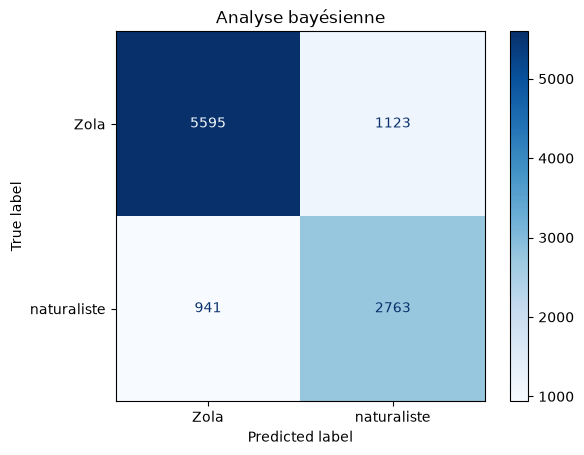

In [22]:
modele_bayes = MultinomialNB(alpha=1)

modele_bayes.fit(X_train_tfidf, y_train)


predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

### 8.2 Régression logistique

=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.938     0.872     0.904      6718
 naturaliste      0.794     0.896     0.842      3704

    accuracy                          0.880     10422
   macro avg      0.866     0.884     0.873     10422
weighted avg      0.887     0.880     0.882     10422

Matrice de confusion :
[[5856  862]
 [ 387 3317]]


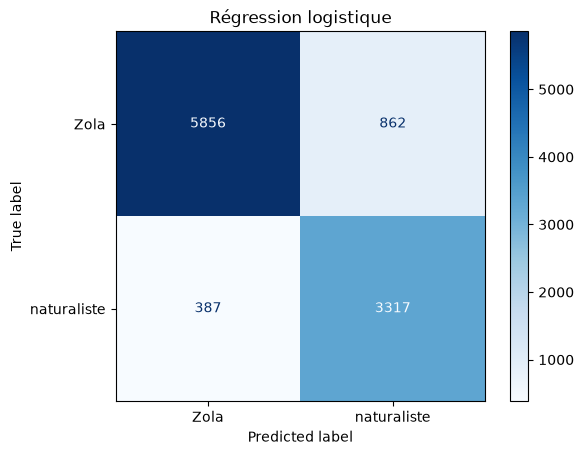

In [23]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()

### 8.3 Analyse discriminante linéaire après réduction SVD

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.

=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.143
              precision    recall  f1-score   support

        Zola      0.870     0.840     0.855      6718
 naturaliste      0.727     0.772     0.749      3704

    accuracy                          0.816     10422
   macro avg      0.798     0.806     0.802     10422
weighted avg      0.819     0.816     0.817     10422

Matrice de confusion :
[[5643 1075]
 [ 843 2861]]


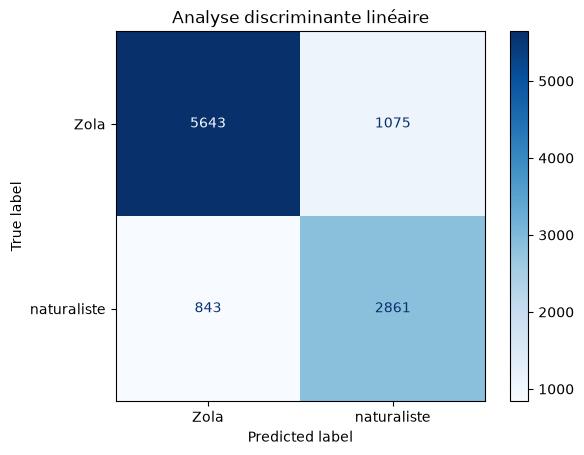

In [24]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


## 9. Comparaison des performances sur le corpus de test

Les résultats du corpus de test sont présentés après la sélection du modèle
par validation croisée. Ils constituent une évaluation complémentaire.

In [11]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

print("\nComparaison des modèles sur le jeu de test :")

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)


Comparaison des modèles sur le jeu de test :


,modèle,accuracy,f1_macro
0,Régression logistique,0.856933,0.846459
1,Analyse discriminante linéaire,0.780824,0.761311
2,Analyse bayésienne,0.772405,0.751491


## 10. Évaluation finale au niveau des œuvres

Les probabilités des segments appartenant à une même œuvre sont moyennées
afin d'obtenir une prédiction unique par œuvre.

In [12]:
probabilites = modele_logistique.predict_proba(
    X_test_tfidf
)

classe_zola = list(
    modele_logistique.classes_
).index("Zola")

evaluation_oeuvres = df_test[
    ["source", "label"]
].copy()

evaluation_oeuvres["probabilite_zola"] = (
    probabilites[:, classe_zola]
)

resultats_oeuvres = (
    evaluation_oeuvres
    .groupby("source")
    .agg(
        label_reel=("label", "first"),
        probabilite_zola=(
            "probabilite_zola",
            "mean"
        )
    )
    .reset_index()
)

resultats_oeuvres["prediction"] = np.where(
    resultats_oeuvres["probabilite_zola"] >= 0.5,
    "Zola",
    "naturaliste"
)

print(
    classification_report(
        resultats_oeuvres["label_reel"],
        resultats_oeuvres["prediction"],
        digits=3
    )
)

resultats_oeuvres

              precision    recall  f1-score   support

        Zola      1.000     1.000     1.000         6
 naturaliste      1.000     1.000     1.000         9

    accuracy                          1.000        15
   macro avg      1.000     1.000     1.000        15
weighted avg      1.000     1.000     1.000        15



,source,label_reel,probabilite_zola,prediction
0,1875_5_La_faute_de_l_abbe_Mouret._clean.txt,Zola,0.759521,Zola
1,1877_7_L_assommoir._clean.txt,Zola,0.801932,Zola
2,1878_8_Une_page_d_amour._clean.txt,Zola,0.749492,Zola
3,1880_9_Nana._clean.txt,Zola,0.747343,Zola
4,1886_14_L_oeuvre._clean.txt,Zola,0.738256,Zola
5,1890_17_La_bete_humaine._clean.txt,Zola,0.775629,Zola
6,Charles Demailly.txt,naturaliste,0.218155,naturaliste
7,En ménage.txt,naturaliste,0.334256,naturaliste
8,Frères_Zemganno.txt,naturaliste,0.266699,naturaliste
9,Georgette.txt,naturaliste,0.201905,naturaliste


## 11. Interprétation des modèles à partir du corpus d'entraînement

Cette section examine les paramètres appris par les modèles, sans tenir
compte de la fréquence des termes dans le corpus de test.

### 11.1 Termes caractéristiques selon Naive Bayes

In [ ]:
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
prussiens                 3.180
empereur                  2.928
sedan                     2.906
les prussiens             2.849
coron                     2.842
zingueur                  2.743
insurgés                  2.685
les camarades             2.577
le zingueur               2.576
nom dieu                  2.565
foutre                    2.519
mineurs                   2.467
le pis                    2.433
belle normande            2.391
charcuterie               2.391
fenil                     2.359
jésus christ              2.349
bourras                   2.346
clientes                  2.344
vuillet                   2.338
pierron                   2.335
cazenove                  2.327
achevait                  2.320
larsonneau                2.310
obus                      2.308
daigremont                2.307
confections               2.300
entêtait                  2.284
huret              

### 11.2 Coefficients de la régression logistique

In [ ]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
lorsque                        -7.5329
empereur                       -6.1497
qu elle                        -5.8861
ça                             -5.4762
hein                           -5.2230
simplement                     -4.5651
lorsqu                         -4.4362
ce fut                         -4.4018
dut                            -4.1174
tout un                        -4.0881
ce pas                         -3.9512
oncle                          -3.9337
justement                      -3.9025
tout suite                     -3.8675
non non                        -3.6734
finit                          -3.6566
dames                          -3.4267
achevait                       -3.4242
travail                        -3.4219
un instant                     -3.4091
au fond                        -3.3708
bande                          -3.3691
ville                          -3.3395
ces messieurs            

## 12. Analyse post-hoc du corpus de test

Cette section examine les termes effectivement présents dans le corpus de
test. Elle est uniquement interprétative et n'est pas utilisée pour
modifier le prétraitement, sélectionner le modèle ou régler ses
hyperparamètres.

### 12.1 Présence et poids TF-IDF des termes dans le test

In [ ]:
# Utilisation du TF-IDF commun
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9886


### 12.2 Termes discriminants de Naive Bayes présents dans le test

In [ ]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}")


Termes présents dans le test les plus caractéristiques de Zola :
prussiens                 score=3.180  extraits=4
empereur                  score=2.928  extraits=19
les prussiens             score=2.849  extraits=2
les camarades             score=2.577  extraits=12
nom dieu                  score=2.565  extraits=56
mineurs                   score=2.467  extraits=1
le pis                    score=2.433  extraits=6
charcuterie               score=2.391  extraits=1
jésus christ              score=2.349  extraits=3
clientes                  score=2.344  extraits=3
achevait                  score=2.320  extraits=54
confections               score=2.300  extraits=1
entêtait                  score=2.284  extraits=19
fit remarquer             score=2.255  extraits=11
murmura il                score=2.254  extraits=76
dossiers                  score=2.248  extraits=3
beauce                    score=2.198  extraits=1
salon jaune               score=2.185  extraits=1
mes bottes                s

### 12.3 Contribution lexicale globale dans le corpus de test

L'indicateur ci-dessous combine le caractère discriminant appris par
Naive Bayes avec le poids TF-IDF total du terme dans le corpus de test.

Il s'agit d'un indicateur descriptif global. Il ne représente pas une
explication locale exacte de chaque prédiction.

In [ ]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)


print(contributions_zola[["terme", "contribution_test"]])
print(contributions_naturalistes[["terme", "contribution_test"]])

           terme  contribution_test
2552        elle         238.606649
9713          ça         143.429962
9853       était         133.713991
7061     qu elle         128.520458
604        avait         119.553406
5024     lorsque          78.931112
3806        hein          71.936825
4755         les          71.570691
7056          qu          67.321875
5017      lorsqu          64.800066
4101         ils          60.840606
2564  elle avait          59.855512
8967        très          56.620072
1797        cria          56.523886
2671  elle était          56.173344
3179         eut          52.732382
5120          là          51.308161
3940    il avait          50.795238
3920          il          50.755808
5671     murmura          49.383994
9375      venait          49.205671
9068     un coup          48.930655
9095  un instant          45.843401
2836      encore          45.182413
8622  tandis que          44.827622
1882       dames          44.239073
3184      eut un          43

## 13. Conclusion

La régression logistique obtient les meilleures performances parmi les
trois modèles étudiés, avec un F1 macro moyen d'environ 0,81 en validation
croisée groupée. Elle atteint également un F1 macro d'environ 0,85 sur le
corpus de test.

La validation croisée est groupée par œuvre : les segments issus d'une même
œuvre ne peuvent pas apparaître simultanément dans l'entraînement et la
validation. Cette précaution limite le risque que le modèle reconnaisse une
œuvre déjà rencontrée.

Les neuf œuvres du corpus de test sont correctement classées après agrégation
des probabilités par œuvre. Ce résultat est encourageant, mais doit être
interprété avec prudence en raison du faible nombre d'œuvres évaluées.

L'écart entre le F1 d'entraînement et le F1 de validation indique néanmoins
un certain surapprentissage. Par ailleurs, malgré le retrait d'une liste
étendue de noms propres, le modèle continue d'exploiter des indices
lexicaux, thématiques, dialectaux et stylistiques propres aux œuvres.

Cette expérience sera comparée à une seconde configuration conservant les
noms propres, tous les autres paramètres du protocole restant identiques.